##  Regresión Multivariada 
### Selección de variables predictoras

Dr. Hugo García Tecocoatzi

In [1]:
#  Importar bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.feature_selection import f_regression, SelectKBest

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline

Vamos a cargar la base de datos de Real Estate para la actividad:

In [2]:
# Crear DataFrame
df = pd.read_csv('../../data/Realestate.csv')


print(f"Forma del dataset: {df.shape}")
print("\nPrimeras 5 filas:")
df.head()

Forma del dataset: (414, 8)

Primeras 5 filas:


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
# Estadísticas descriptivas
print("ESTADÍSTICAS DESCRIPTIVAS\n")
print(df.describe().round(2))

ESTADÍSTICAS DESCRIPTIVAS

           No  X1 transaction date  X2 house age  \
count  414.00               414.00        414.00   
mean   207.50              2013.15         17.71   
std    119.66                 0.28         11.39   
min      1.00              2012.67          0.00   
25%    104.25              2012.92          9.02   
50%    207.50              2013.17         16.10   
75%    310.75              2013.42         28.15   
max    414.00              2013.58         43.80   

       X3 distance to the nearest MRT station  \
count                                  414.00   
mean                                  1083.89   
std                                   1262.11   
min                                     23.38   
25%                                    289.32   
50%                                    492.23   
75%                                   1454.28   
max                                   6488.02   

       X4 number of convenience stores  X5 latitude  X6 longit

In [4]:
# Matriz de correlación detallada
print("\nMATRIZ DE CORRELACIÓN\n")
print(df.corr().round(3))


MATRIZ DE CORRELACIÓN

                                           No  X1 transaction date  \
No                                      1.000               -0.049   
X1 transaction date                    -0.049                1.000   
X2 house age                           -0.033                0.018   
X3 distance to the nearest MRT station -0.014                0.061   
X4 number of convenience stores        -0.013                0.010   
X5 latitude                            -0.010                0.035   
X6 longitude                           -0.011               -0.041   
Y house price of unit area             -0.029                0.087   

                                        X2 house age  \
No                                            -0.033   
X1 transaction date                            0.018   
X2 house age                                   1.000   
X3 distance to the nearest MRT station         0.026   
X4 number of convenience stores                0.050   
X5 latitu

### Preguntas

1. ¿Qué variables tienen mayor correlación con el Precio?

Aquellas variables que mantienen mayor correlacion son el tamaño y las habitaciones, ambas con un valor positivo mayor a $0.9$. Por lo que estas afectan en gran medida el comportamiento del precio. Mientras mayor la cantidad de habitaciones y el tamaño de la casa, mayor el precio (algo logico a primer vista).

2. ¿Hay variables altamente correlacionadas entre sí? ¿Cuáles?

Aunque algunas tienen una correlación notable, la que si es por mucho la que brinca mas es la relación entre el tamaño y las habitaciones con un valor de correlación de $0.956$.

3. ¿Cómo crees que afecta cada variable al precio?"

Como fue mencionado antes, el tamaño y las habitaciones afectan en gran medida al precio de manera positiva. Asimismo, la ubicación tiene una muy pequeña correlación con el precio, por lo que es posible que no afecte en si. Por otro lado, la antigüedad tiene un ligero grado de correlación negativa (mientras menos vieja es la casa, mayor el precio).

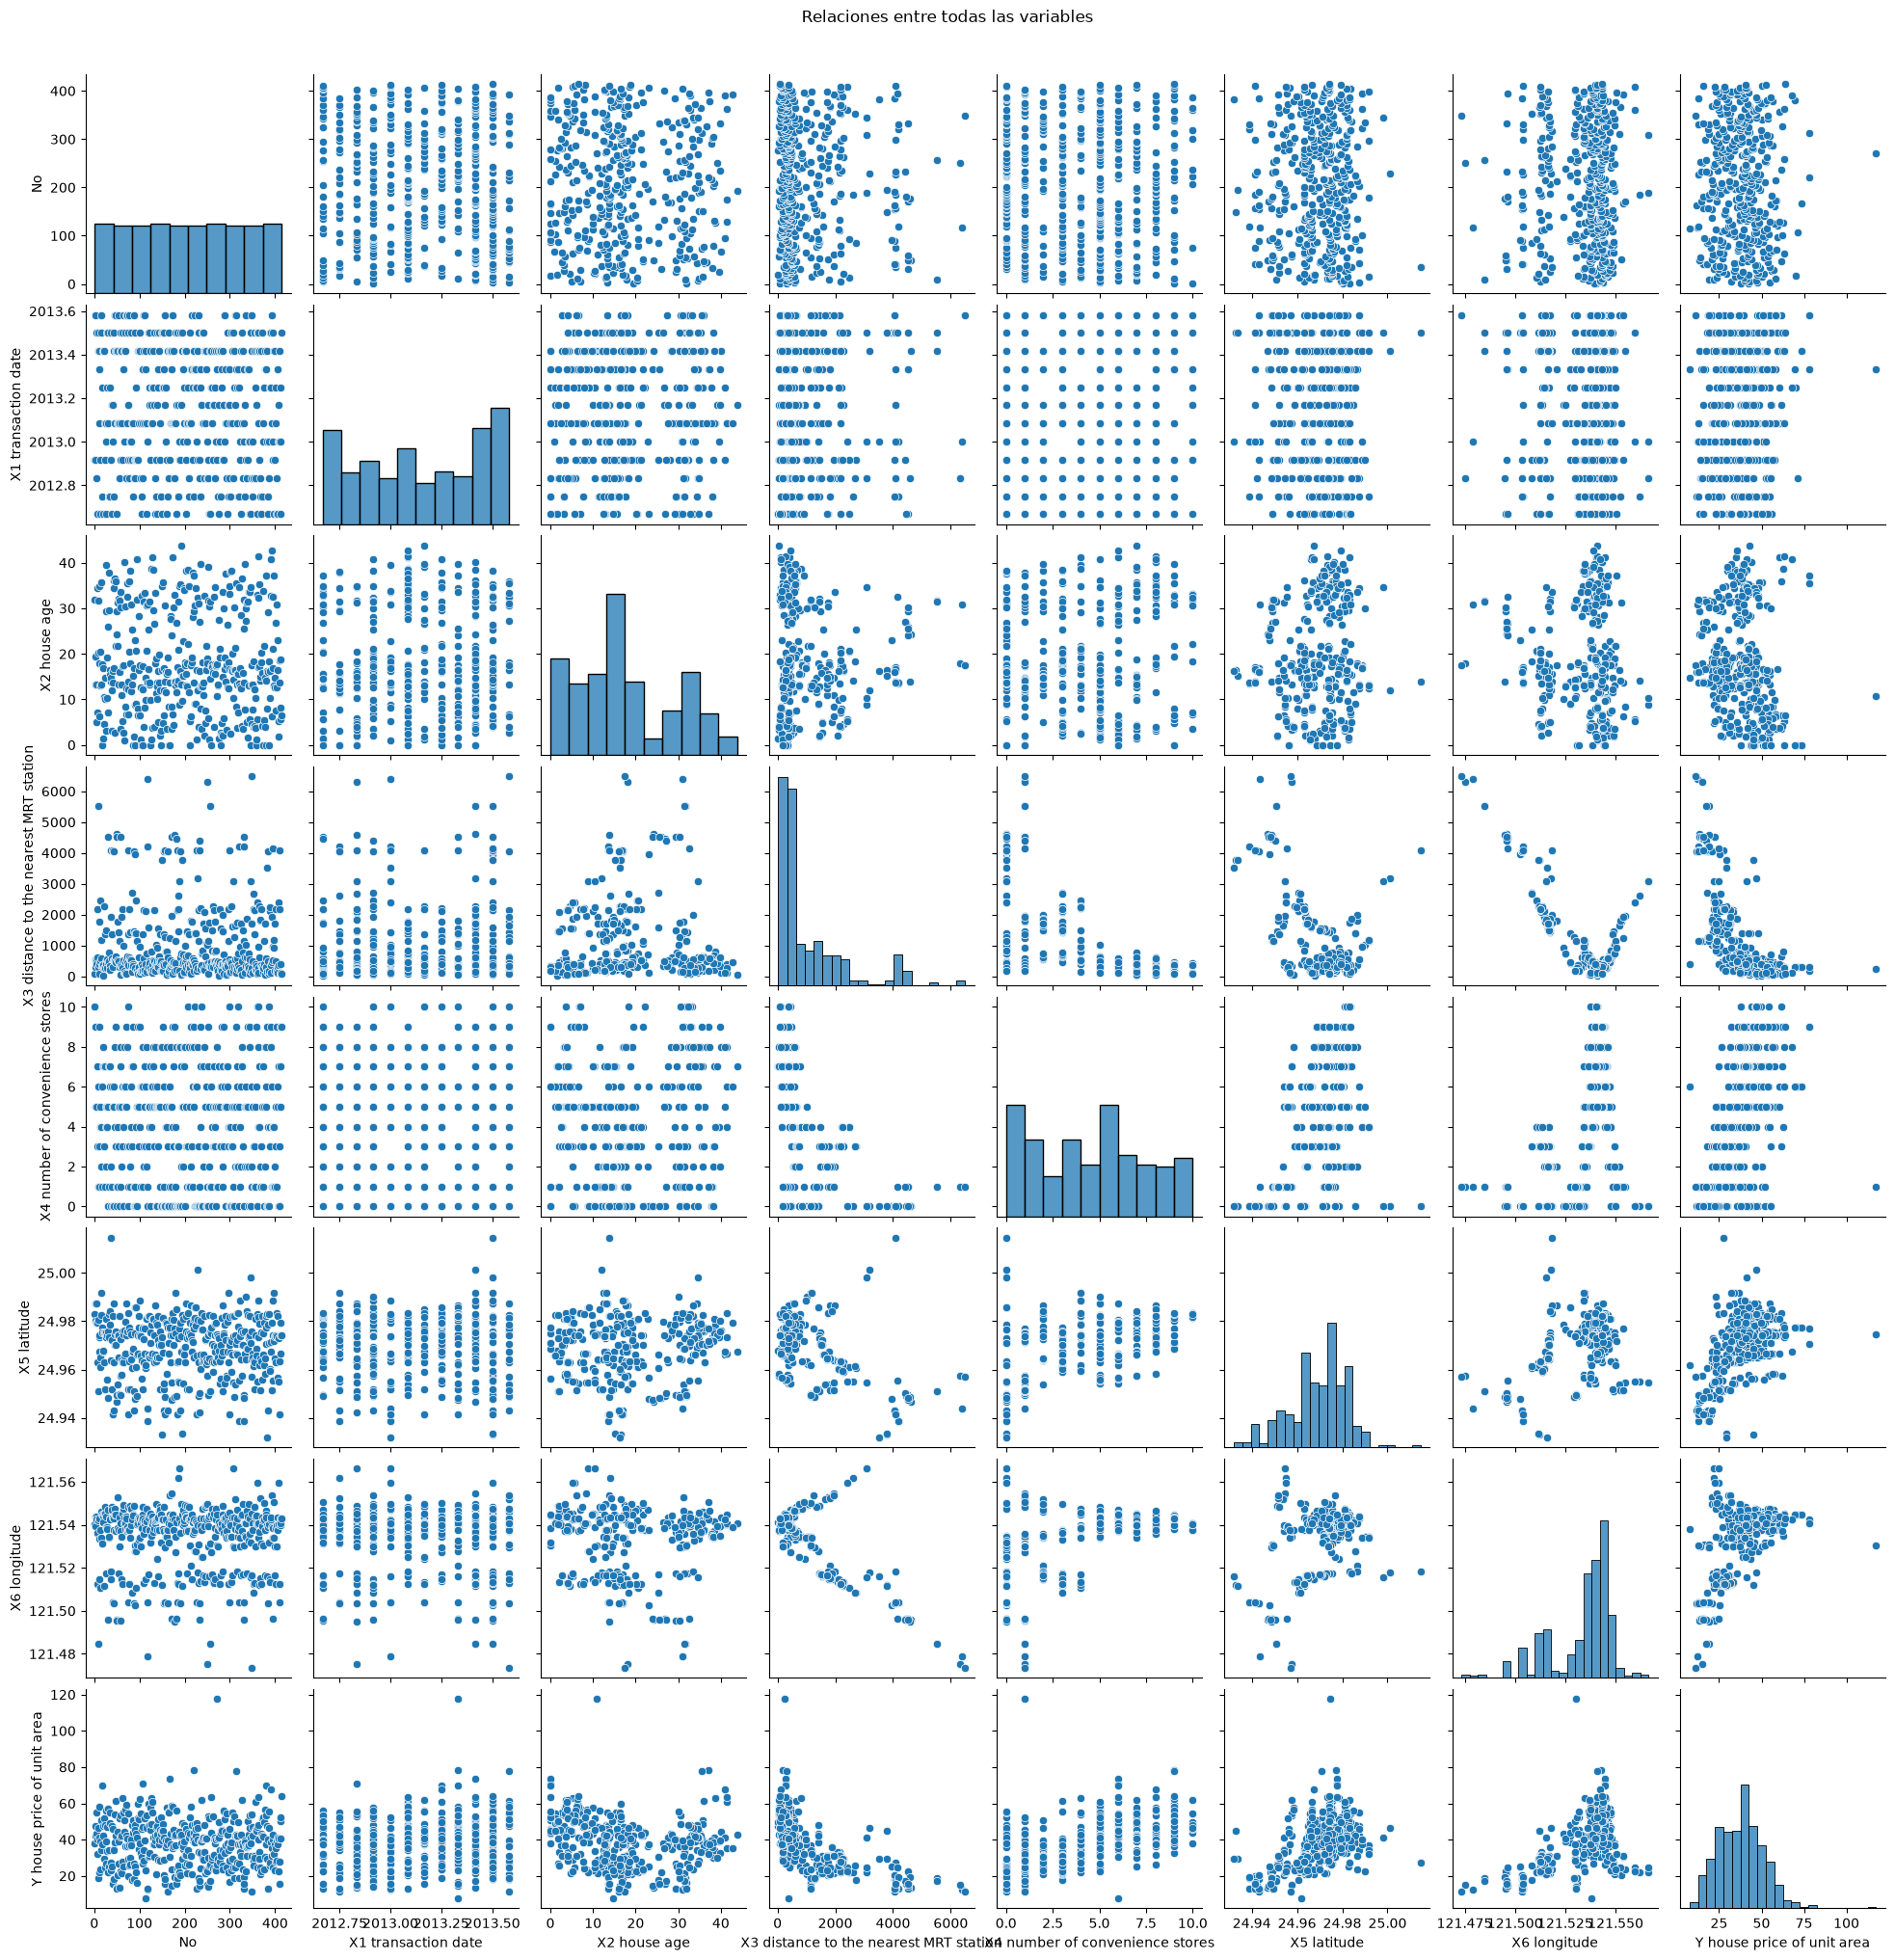

In [5]:
# Pairplot de variables
sns.pairplot(df)
plt.suptitle('Relaciones entre todas las variables', y=1.02)
plt.show()

In [6]:
#  Dividir datos en entrenamiento y prueba
X = df.drop('Y house price of unit area', axis=1)
y = df['Y house price of unit area']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño de prueba: {X_test.shape[0]} muestras")

Tamaño de entrenamiento: 289 muestras
Tamaño de prueba: 125 muestras


In [7]:
# Entrenar modelo de regresión lineal con todas las variables
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Mostrar coeficientes
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})
print("=== COEFICIENTES DEL MODELO ===\n")
print(coeficientes)
print(f"\nIntercept (término constante): {modelo.intercept_:.4f}")

=== COEFICIENTES DEL MODELO ===

                                 Variable  Coeficiente
0                                      No    -0.006260
1                     X1 transaction date     5.859783
2                            X2 house age    -0.239516
3  X3 distance to the nearest MRT station    -0.005230
4         X4 number of convenience stores     1.064933
5                             X5 latitude   236.128176
6                            X6 longitude   -54.468708

Intercept (término constante): -11027.8852


In [8]:
# Evaluar modelo completo
y_pred = modelo.predict(X_test)

MAE = metrics.mean_absolute_error(y_test, y_pred)
MSE = metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = metrics.r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN ===\n")
print(f"Error Absoluto Medio (MAE): {MAE:.4f}")
print(f"Error Cuadrático Medio (MSE): {MSE:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {RMSE:.4f}")
print(f"R² (Coeficiente de Determinación): {R2:.4f}")

=== MÉTRICAS DE EVALUACIÓN ===

Error Absoluto Medio (MAE): 6.2664
Error Cuadrático Medio (MSE): 74.7087
Raíz del Error Cuadrático Medio (RMSE): 8.6434
R² (Coeficiente de Determinación): 0.5532


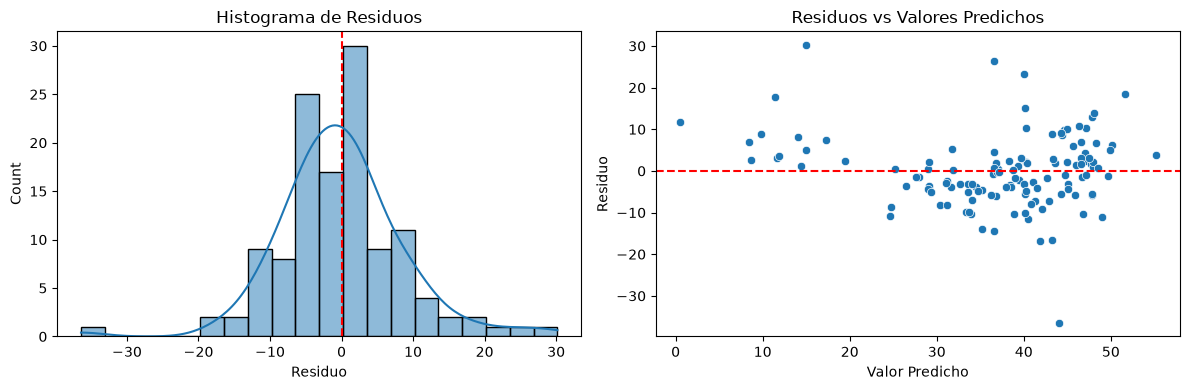

Media de residuos: -0.0900
Desviación estándar de residuos: 8.6777


In [9]:
# Análisis de residuos
residuos = y_test - y_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, bins=20)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Histograma de Residuos')
plt.xlabel('Residuo')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Valores Predichos')
plt.xlabel('Valor Predicho')
plt.ylabel('Residuo')

plt.tight_layout()
plt.show()

print(f"Media de residuos: {residuos.mean():.4f}")
print(f"Desviación estándar de residuos: {residuos.std():.4f}")

In [10]:
# Cálculo del VIF (Factor de Inflación de la Varianza)
X_constant = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_constant.columns
vif_data["VIF"] = [variance_inflation_factor(X_constant.values, i) 
                   for i in range(X_constant.shape[1])]

print("=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===\n")
print(vif_data)
print("\n Recuerda:")
print("- VIF > 5: indica alta multicolinealidad")
print("- VIF > 10: indica multicolinealidad severa")

=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===

                                 Variable           VIF
0                                   const  2.431196e+08
1                                      No  1.005872e+00
2                     X1 transaction date  1.016623e+00
3                            X2 house age  1.015215e+00
4  X3 distance to the nearest MRT station  4.332646e+00
5         X4 number of convenience stores  1.617793e+00
6                             X5 latitude  1.610771e+00
7                            X6 longitude  2.931428e+00

 Recuerda:
- VIF > 5: indica alta multicolinealidad
- VIF > 10: indica multicolinealidad severa


In [11]:
#  Selección hacia adelante (Forward Selection)
def forward_selection(X, y, threshold=0.05):
    """
    Selección de variables hacia adelante basada en p-valor
    """
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        
        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_col]]))).fit()
            new_pval[new_col] = model.pvalues[new_col]
        
        best_pval = new_pval.min()
        if best_pval < threshold:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
        
        if not changed:
            break
    
    return included

print("=== SELECCIÓN HACIA ADELANTE ===\n")
variables_seleccionadas = forward_selection(X, y)
print(f"Variables seleccionadas: {variables_seleccionadas}")

=== SELECCIÓN HACIA ADELANTE ===

Variables seleccionadas: ['X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X2 house age', 'X5 latitude', 'X1 transaction date']


In [12]:
# Comparación de modelos con diferentes variables
print("=== COMPARACIÓN DE MODELOS ===\n")

combinaciones = [
    list(X.columns),  # Modelo completo
    variables_seleccionadas
]

nombres_combinaciones = [
    'Modelo completo',
    'Modelo con variables seleccionadas (Forward)'
]

for nombre, vars_list in zip(nombres_combinaciones, combinaciones):
    X_sel = sm.add_constant(X[vars_list])
    model = sm.OLS(y, X_sel).fit()
    
    print(f"📊 {nombre}")
    print(f"  Variables: {vars_list}")
    print(f"  R² = {model.rsquared:.4f}")
    print(f"  R² ajustado = {model.rsquared_adj:.4f}")
    print(f"  AIC = {model.aic:.2f}")
    print(f"  BIC = {model.bic:.2f}")
    print()

=== COMPARACIÓN DE MODELOS ===

📊 Modelo completo
  Variables: ['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
  R² = 0.5834
  R² ajustado = 0.5762
  AIC = 2988.94
  BIC = 3021.15

📊 Modelo con variables seleccionadas (Forward)
  Variables: ['X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X2 house age', 'X5 latitude', 'X1 transaction date']
  R² = 0.5823
  R² ajustado = 0.5772
  AIC = 2985.99
  BIC = 3010.15



In [13]:
# Análisis detallado del mejor modelo
print("=== MEJOR MODELO SEGÚN FORWARD SELECTION ===\n")

X_sel = sm.add_constant(X[variables_seleccionadas])
modelo_final = sm.OLS(y, X_sel).fit()
print(modelo_final.summary())

=== MEJOR MODELO SEGÚN FORWARD SELECTION ===

                                OLS Regression Results                                
Dep. Variable:     Y house price of unit area   R-squared:                       0.582
Model:                                    OLS   Adj. R-squared:                  0.577
Method:                         Least Squares   F-statistic:                     113.8
Date:                        Fri, 11 Sep 2026   Prob (F-statistic):           4.47e-75
Time:                                16:43:08   Log-Likelihood:                -1487.0
No. Observations:                         414   AIC:                             2986.
Df Residuals:                             408   BIC:                             3010.
Df Model:                                   5                                         
Covariance Type:                    nonrobust                                         
                                             coef    std err          t      P>|t|  

In [14]:
# Evaluación del mejor modelo en test
X_train_sel = X_train[variables_seleccionadas]
X_test_sel = X_test[variables_seleccionadas]

modelo_sel = LinearRegression()
modelo_sel.fit(X_train_sel, y_train)

y_pred_sel = modelo_sel.predict(X_test_sel)

MAE_sel = metrics.mean_absolute_error(y_test, y_pred_sel)
MSE_sel = metrics.mean_squared_error(y_test, y_pred_sel)
RMSE_sel = np.sqrt(MSE_sel)
R2_sel = metrics.r2_score(y_test, y_pred_sel)

print("=== COMPARACIÓN DE RENDIMIENTO ===\n")
print("Modelo Completo vs Modelo Seleccionado:")

print(f"\nModelo Completo (todas las variables):")
print(f"  MAE: {MAE:.4f}")
print(f"  RMSE: {RMSE:.4f}")
print(f"  R²: {R2:.4f}")

print(f"\nModelo Seleccionado ({variables_seleccionadas}):")
print(f"  MAE: {MAE_sel:.4f}")
print(f"  RMSE: {RMSE_sel:.4f}")
print(f"  R²: {R2_sel:.4f}")

=== COMPARACIÓN DE RENDIMIENTO ===

Modelo Completo vs Modelo Seleccionado:

Modelo Completo (todas las variables):
  MAE: 6.2664
  RMSE: 8.6434
  R²: 0.5532

Modelo Seleccionado (['X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X2 house age', 'X5 latitude', 'X1 transaction date']):
  MAE: 6.1424
  RMSE: 8.5266
  R²: 0.5652


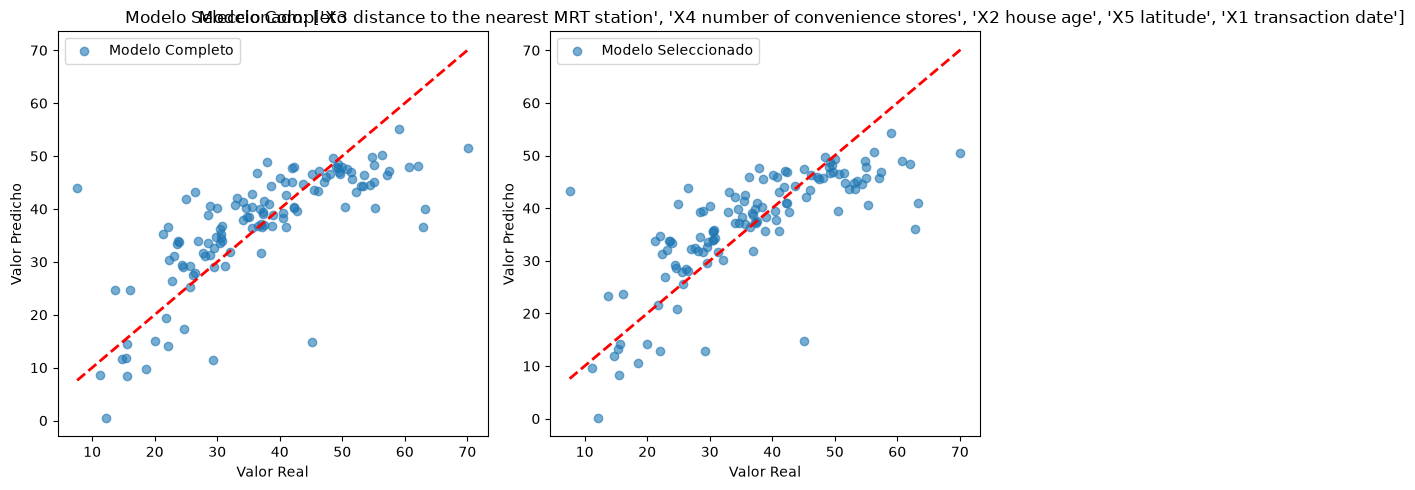

In [15]:
# Visualización del modelo seleccionado
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, label='Modelo Completo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Modelo Completo')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sel, alpha=0.6, label='Modelo Seleccionado')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title(f'Modelo Seleccionado: {variables_seleccionadas}')
plt.legend()

plt.tight_layout()
plt.show()

## Actividad Final

Utiliza este notebook para ver qué varibles debes eliminar de la base de datos de Real Estate